# Практическая работа №5. Библиотека Pandas. Визуальный анализ данных

## Комплексное задание №1. Применение основных методов для анализа данных

1. Скачайте этот блокнот к себе.
2. Заполните пропущенные ячейки, отвечая на заданные вопросы. Там должен быть код! (если не сказано обратное)
3. Сохраните результат в своём гитхаб репозитории.

#### Полезная литература
- [**Блокнот с теорией**](https://colab.research.google.com/drive/1SLqmaYz4xEsxVV-LGwb3ityheBTzHJQu?usp=sharing)
- http://pandas.pydata.org/pandas-docs/stable/10min.html
- https://pandas.pydata.org/pandas-docs/stable/indexing.html
- https://pandas.pydata.org/pandas-docs/stable/missing_data.html

В этом задании мы с Вами рассмотрим датасет [Adult Data Set](https://archive.ics.uci.edu/ml/datasets/Adult).
Основывается он на данных переписи населения 1994 года в США.

Расшифровка содержимого колонок:

- age: continuous.
- workclass: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked.
- fnlwgt: continuous. sampling weight, more here: SIPP Weighting.
- education: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool.
- education-num: continuous.
- marital-status: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse.
- occupation: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces.
- relationship: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried.
- race: White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black.
- sex: Female, Male.
- capital-gain: continuous. Income from investment sources, apart from wages/salary.
- capital-loss: continuous. Losses from investment sources, apart from wages/salary.
- hours-per-week: continuous.
- native-country: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.__version__

'3.0.1'

Если вы увидели warning, не переживайте, всё хорошо.
- https://stackoverflow.com/questions/40845304/runtimewarning-numpy-dtype-size-changed-may-indicate-binary-incompatibility
- https://github.com/numpy/numpy/pull/432

In [2]:
columns='age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income'.split(',')
# df = pd.read_csv('../../data/adult.csv.gz', na_values='?') # можно загрузить из файла или URL
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data', na_values=' ?', names=columns)
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
df.tail(10)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
32551,32,Private,34066,10th,6,Married-civ-spouse,Handlers-cleaners,Husband,Amer-Indian-Eskimo,Male,0,0,40,United-States,<=50K
32552,43,Private,84661,Assoc-voc,11,Married-civ-spouse,Sales,Husband,White,Male,0,0,45,United-States,<=50K
32553,32,Private,116138,Masters,14,Never-married,Tech-support,Not-in-family,Asian-Pac-Islander,Male,0,0,11,Taiwan,<=50K
32554,53,Private,321865,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,>50K
32555,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


1) Выведите последние 10 элеметнов датасета

In [4]:
df.shape

(32561, 15)

2) Сколько колонок и сколько строк в этом датасете?

In [5]:
df.dtypes

age               int64
workclass           str
fnlwgt            int64
education           str
education.num     int64
marital.status      str
occupation          str
relationship        str
race                str
sex                 str
capital.gain      int64
capital.loss      int64
hours.per.week    int64
native.country      str
income              str
dtype: object

3) Какие типы данных у элементов этого датасета?

In [6]:
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

4) Какие признаки имеют пропуски?

In [ ]:
Пропуски, скорее всего, связаны с тем, что человек не указал определённые сведения при заполнении данных. Например, `workclass`, `occupation` и `native.country` могут быть неизвестны или не заполнены. Поэтому Pandas показывает такие значения как пропуски.

5) Как вы думаете, с чем связаны пропуски этих значение. Напишите развернутый ответ в ячейке ниже.

6) Какие и сколько различных рабочих классов workclass представлено в выборке?

In [7]:
print('Средний возраст женщин:', df[df['sex'] == ' Female']['age'].mean())
print('Средний возраст мужчин:', df[df['sex'] == ' Male']['age'].mean())

Средний возраст женщин: 36.85823043357163
Средний возраст мужчин: 39.43354749885268


7) Какой средний возраст женщин и мужчин?

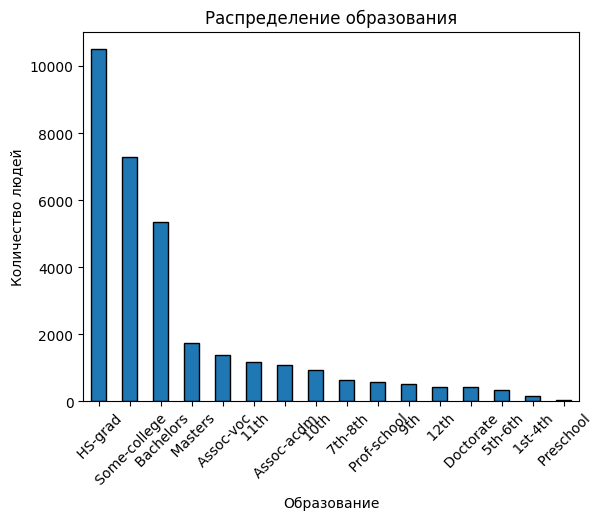

In [8]:
df['education'].value_counts().plot(kind='bar', edgecolor='black')
plt.xlabel('Образование')
plt.ylabel('Количество людей')
plt.title('Распределение образования')
plt.xticks(rotation=45)
plt.show()

8) Постройте гистограмму(bar) распределения образования людей (education)

In [9]:
print('Больше 50K:')
print(df[df['income'] == ' >50K']['age'].agg(['mean', 'std']))
print()
print('Не больше 50K:')
print(df[df['income'] == ' <=50K']['age'].agg(['mean', 'std']))

Больше 50K:
mean    44.249841
std     10.519028
Name: age, dtype: float64

Не больше 50K:
mean    36.783738
std     14.020088
Name: age, dtype: float64


9) Каковы средние значения и среднеквадратичные отклонения возраста тех, кто получает более 50K в год (признак income) и тех, кто получает менее 50K в год?

In [10]:
education = [' Bachelors', ' Prof-school', ' Assoc-acdm', ' Assoc-voc', ' Masters', ' Doctorate']
high = df[df['income'] == ' >50K']
high['education'].isin(education).all()

np.False_

10) Правда ли, что люди, которые получают больше 50k, имеют как минимум высшее образование? (признак education - Bachelors, Prof-school, Assoc-acdm, Assoc-voc, Masters или Doctorate)

In [11]:
men = df[df['sex'] == ' Male'].copy()
men['married'] = men['marital.status'].str.startswith(' Married')
men.groupby('married')['income'].apply(lambda x: (x == ' >50K').mean())

married
False    0.084495
True     0.440514
Name: income, dtype: float64

11) Среди кого больше доля зарабатывающих много (>50K): среди женатых или холостых мужчин (признак marital-status)? Женатыми считаем тех, у кого marital-status начинается с Married (Married-civ-spouse, Married-spouse-absent или Married-AF-spouse), остальных считаем холостыми.

In [12]:
pd.pivot_table(df, values='hours.per.week', index='native.country',
                  columns='income', aggfunc='mean')

income,<=50K,>50K
native.country,,
Cambodia,41.416667,40.000000
Canada,37.914634,45.641026
China,37.381818,38.900000
Columbia,38.684211,50.000000
Cuba,37.985714,42.440000
Dominican-Republic,42.338235,47.000000
Ecuador,38.041667,48.750000
El-Salvador,36.030928,45.000000
England,40.483333,44.533333


12) Постройте [сводную таблицу](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.pivot_table.html) для отображения зависимостей среднего времени работы (hours.per.week) с доходом (income) для каждой страны (native.country).  


> Пример фрагмента таблицы:



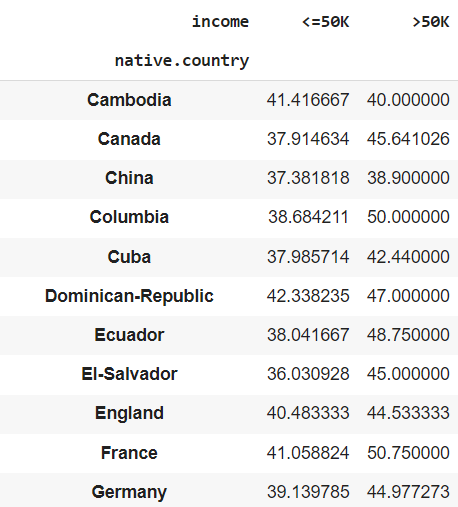

In [13]:
summary_table = pd.DataFrame()
summary_table['education'] = df['education']
summary_table['capital.diff'] = df['capital.gain'] - df['capital.loss']
summary_table = summary_table[summary_table['capital.diff'] != 0]
summary_table['categories'] = pd.qcut(summary_table['capital.diff'], q=10)
pd.pivot_table(summary_table, values='capital.diff', index='education',
               columns='categories', aggfunc='count', fill_value=0)

categories,"(-4356.001, -1977.0]","(-1977.0, -1887.0]","(-1887.0, -1594.0]","(-1594.0, 2174.0]","(2174.0, 3137.0]","(3137.0, 4787.0]","(4787.0, 7298.0]","(7298.0, 8614.0]","(8614.0, 15024.0]","(15024.0, 99999.0]"
education,,,,,,,,,,
10th,11,4,10,13,11,9,3,1,2,4
11th,10,3,14,17,9,12,10,6,5,0
12th,1,0,6,8,2,5,1,3,3,1
1st-4th,2,0,2,1,0,3,0,1,0,0
5th-6th,6,2,2,3,3,4,5,0,0,0
7th-8th,7,3,9,10,19,7,6,2,1,0
9th,1,0,7,13,9,7,2,0,0,1
Assoc-acdm,14,15,17,16,13,12,14,16,17,3
Assoc-voc,19,13,12,18,22,31,34,16,19,4


13) Постройте сводную таблицу для сравнения уровня образования и разности между capital.gain и capital.loss по следующему алгоритму:&nbsp;  
1. Создайте вспомогательную таблицу (датафрейм) и добавьте в неё столбец "education" из целевой таблицы
2. Добавьте во вспомогательную таблицу ещё один столбец "capital.diff", значиниями которого будут являться разности столбцов capital.gain и capital.loss целевой таблицы
3. Удалите во вспомогательной таблице все строки, в которых значение столбца "capital.diff" равно нулю  
&nbsp; Подсказка:
```
summary_table = summary_table[summary_table['capital.diff'] != 0 ]
```
4. Для набора значений из столбца "capital.diff", необходимо сформировать 10 категорий (кластеров), это можно сделать с помощью математических функций, типа log, извлечение корня N-ой степени и округления, для последующего перехода к категориальным признакам.  
  * В нашем случае, можно воспользоваться методом [pd.qcut()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.qcut.html) и равномерно разделить наш набор данных на целевое количество категорий
5. Добавьте во вспомогательную таблицу столбец "categories", и проинициализируйте его значениями категорий, которые возвращает метод pd.qcut()  
&nbsp; Пример:
```
summary_table['categories'] = pd.qcut(summary_table["capital.diff"], q = 10)

6. Постройте сводную таблицу с помощью метода pivot_table(),

Примерная структура таблицы (в качестве значений выводится количество людей, относящихся к той или иной группе):

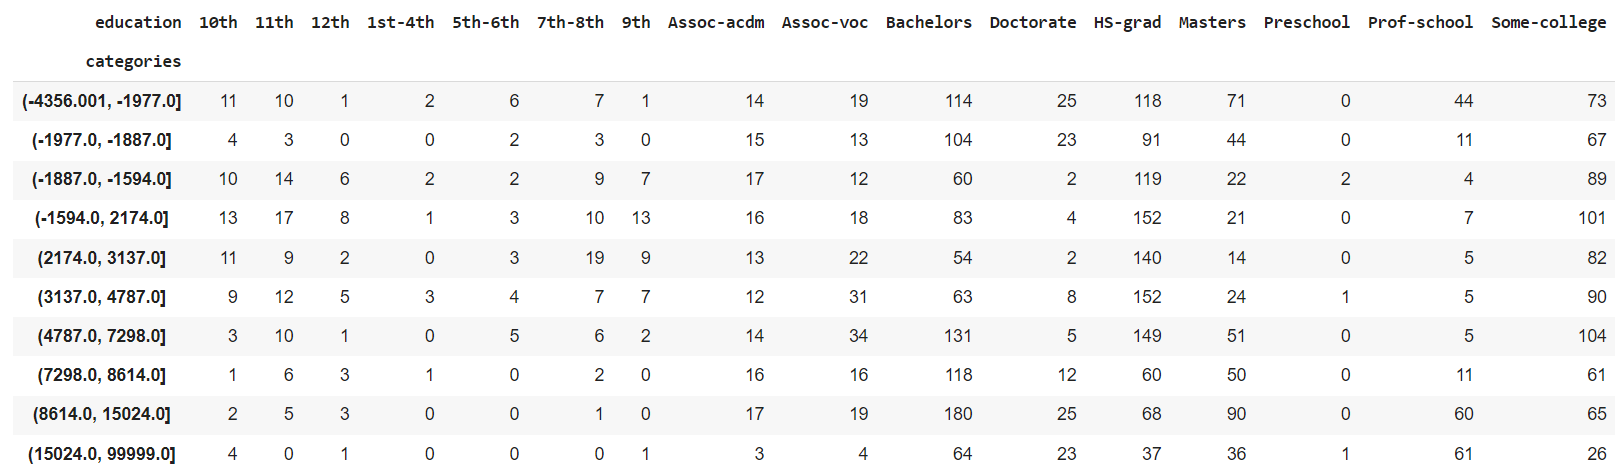

In [14]:
women = df[df['sex'] == ' Female'].copy()
women['high_income'] = women['income'] == ' >50K'
women.groupby('native.country')['high_income'].mean().sort_values(ascending=False)

native.country
Yugoslavia                    0.333333
Taiwan                        0.266667
France                        0.250000
Iran                          0.250000
Japan                         0.250000
Italy                         0.238095
China                         0.238095
Canada                        0.230769
Greece                        0.200000
Scotland                      0.200000
England                       0.187500
India                         0.181818
Portugal                      0.166667
Hong                          0.166667
Hungary                       0.166667
Philippines                   0.164384
Honduras                      0.142857
Ireland                       0.142857
Laos                          0.125000
Germany                       0.116667
United-States                 0.110721
Poland                        0.105263
South                         0.100000
Thailand                      0.090909
Nicaragua                     0.083333
Cuba      

14) Женщины из каких стран получают в среднем большую зарплату (>50K) чаще.

In [15]:
np.random.seed(1)
df['magic_salary'] = np.where(
    df['income'] == ' <=50K',
    np.random.randint(0, 51, size=len(df)),
    np.random.randint(51, 201, size=len(df))
)
df.groupby('education')['magic_salary'].mean()

education
10th             31.654877
11th             31.080851
12th             31.907621
1st-4th          28.446429
5th-6th          28.213213
7th-8th          31.365325
9th              30.535019
Assoc-acdm       50.017807
Assoc-voc        51.158466
Bachelors        66.416246
Doctorate        99.600484
HS-grad          41.276164
Masters          78.973883
Preschool        24.627451
Prof-school     100.625000
Some-college     44.395830
Name: magic_salary, dtype: float64

15) Создайте случайную колонку - magic_salary, которую нужно будет вычислить следующим образом: если зарплата небольшая (<50K), тогда случайно выберите число из диапазона [0,50]. Если зарплата выше 50K тогда из диапазона [51, 200]. Посчитайте среднюю зарплату в час для групп людей с одни уровнем образования на основе нашей случайной колонки magic_salary

## Комплексное задание №2. Визуальный анализ данных. Часть 1

In [16]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

В этом задании Вам предлагается провести визуальный анализ датасета о прокатах велосипедов https://www.kaggle.com/c/bike-sharing-demand/data. Оригинальная задача предполагает построение модели предсказания количества прокатов в городе в зависимости от погоды.

В этом датасете используются следующие столбцы:
- instant: порядковый номер дня
- dteday: дата
- season: 1 - весна, 2 - лето, 3 - осень, 4 - зима
- yr: 0 - 2011, 1 - 2012
- mnth: от 1 до 12
- holiday: 0 - нет праздника, 1 - есть праздник
- weekday: от 0 до 6
- workingday: 0 - нерабочий день, 1 - рабочий день
- weathersit: оценка благоприятности погоды от 1 до 4
- temp: температура
- atemp: температура по ощущениям
- hum: влажность
- windspeed: скорость ветра
- casual: количество прокатов случайными пользователями
- registered: количество прокатов зарегистрированными пользователями
- cnt: общее количество арендованных велосипедов

Загрузите самостоятельно(!), с помощью pandas файл `bikes_rent.csv.gz` и выведите первые 5 строк. Ознакомьтесь с данными с помощью функций describe и info.

In [17]:
df = pd.read_csv('https://raw.githubusercontent.com/danwild/bike-share-prediction/master/Bike-Sharing-Dataset/day.csv')

df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [18]:
df.info()

df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    str    
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 91.5 KB


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


Давайте посмотрим на графиках, как целевой признак зависит количество прокатов (cnt) зависит от остальных признаков `df.columns[:-1]`.

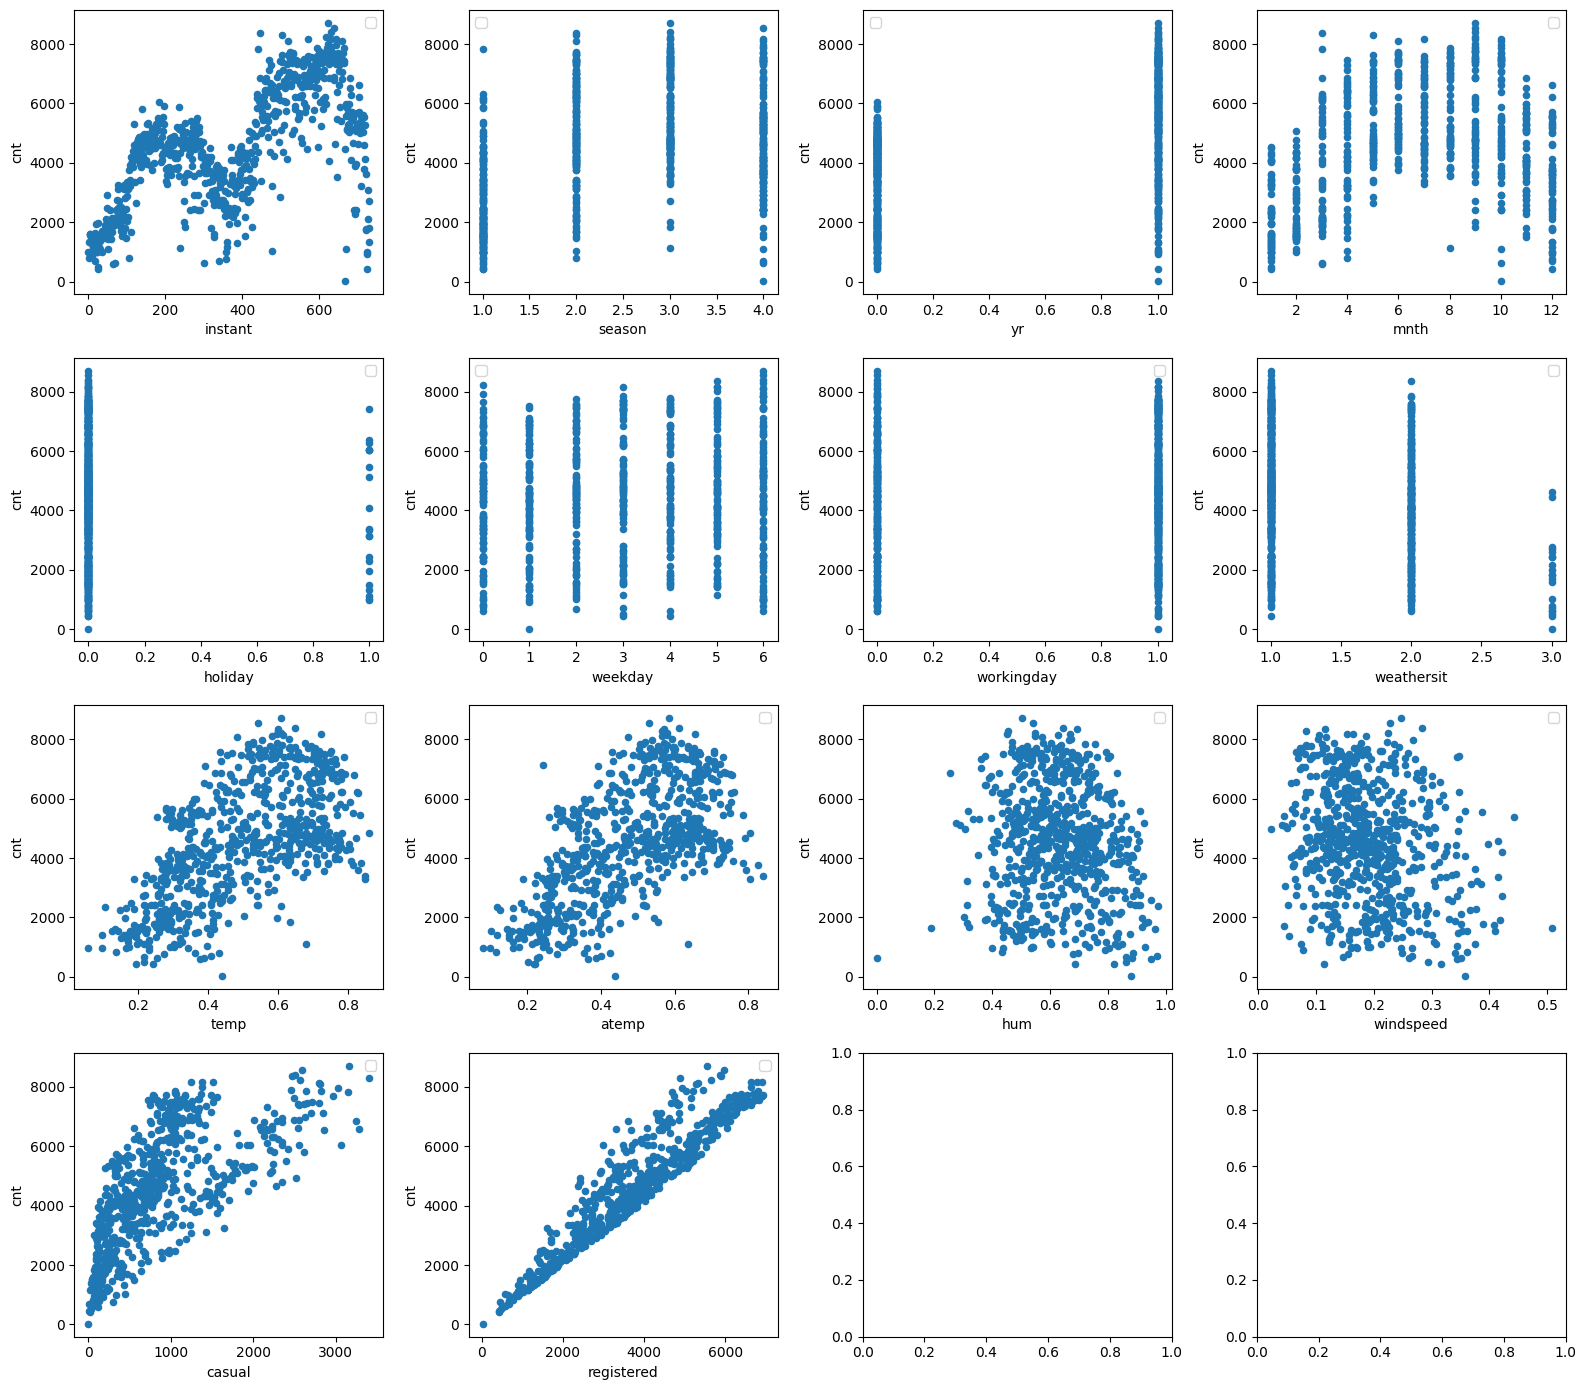

In [19]:
features = df.drop(['dteday', 'cnt'], axis=1).columns

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 14))
for idx, feature in enumerate(features):
    df.plot(feature, 'cnt', subplots=True, kind='scatter', ax=axes[idx // 4, idx % 4])

plt.tight_layout()

Зависимость числа прокатов от месяца нелинейная. Летом и в начале осени прокатов больше, а зимой меньше. При этом по месяцам виден сезонный характер.

ответ:

Ответ:

Среди погодных признаков наиболее близкая к линейной зависимость наблюдается у температуры (`temp`) и температуры по ощущениям (`atemp`). Также заметна связь с годом (`yr`).

Ответ:

### 2. Корреляционная матрица

Напомним, что корреляция отражает взаимосвязь двух случайных величин. Она бывает положительная и отрицательная. Чем ближе коэффициент корреляции к нулю, тем меньше взаимосвязь. Чем больше абсолютная корреляци, тем взаимосвязь больше.

Постройте heatmap корреляционной матрицы. Матрица формируется средствами pandas, со стандартным значением параметров.



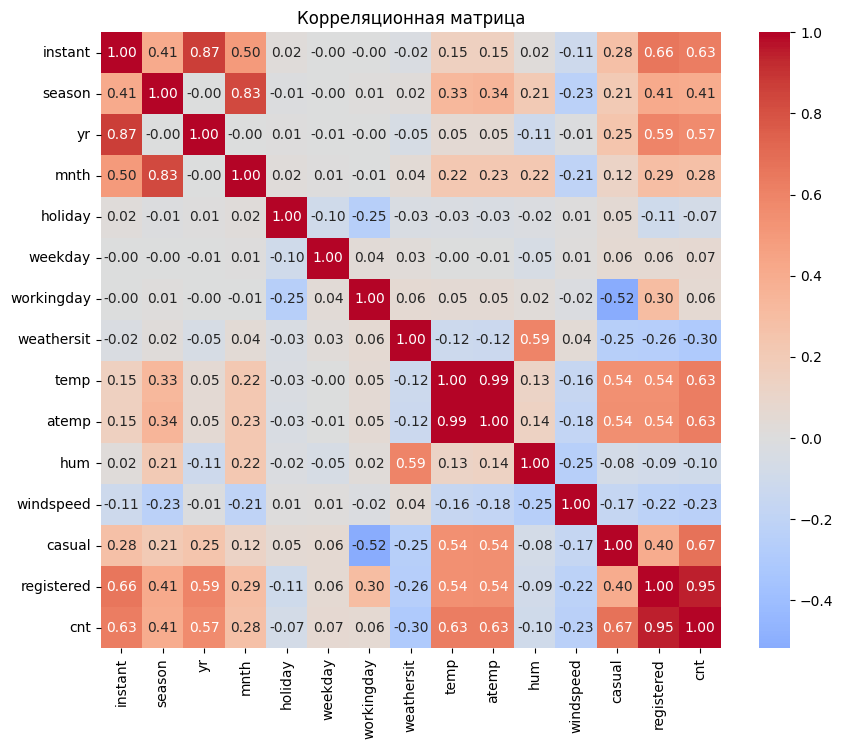

In [29]:
corr = df.drop('dteday', axis=1).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляционная матрица')
plt.show()

В этом датасете сильнее всего с `cnt` связаны `registered` и `casual`, так как общее количество прокатов складывается из этих двух признаков. Среди погодных признаков заметнее всего связаны с `cnt` температура (`temp`) и температура по ощущениям (`atemp`).

Ответ

### 3. Barpot

Постройте Bar-график суммарного количества прокатов велосипедов по месяцам за каждый год одновременно. (будет 24 столбика)



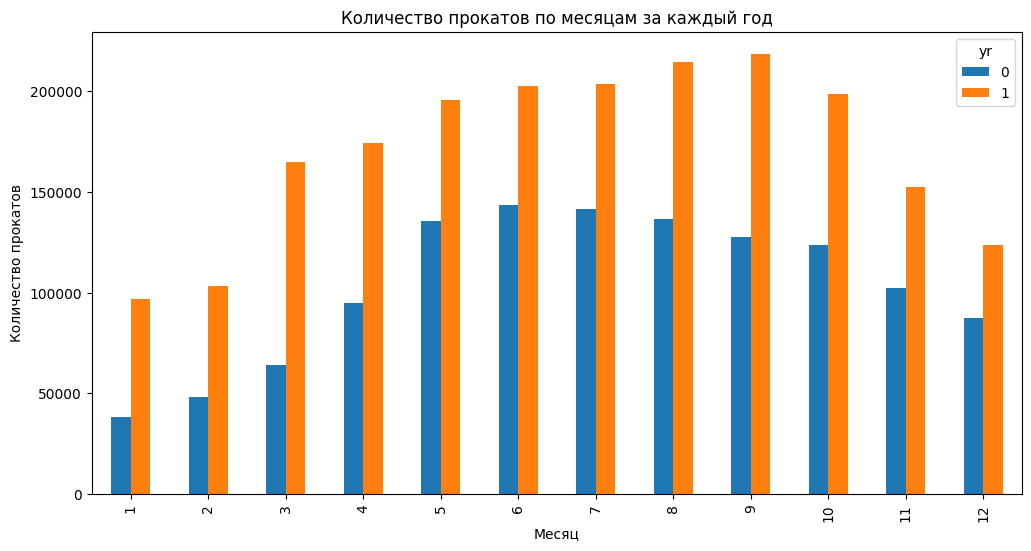

In [22]:
data = df.groupby(['yr', 'mnth'])['cnt'].sum().unstack(0)
data.plot(kind='bar', figsize=(12, 6))
plt.xlabel('Месяц')
plt.ylabel('Количество прокатов')
plt.title('Количество прокатов по месяцам за каждый год')
plt.show()

Корреляция с годом получается заметной потому, что данные разделены на два года: 2011 и 2012. Во втором году количество прокатов в целом стало больше.

Ответ:

### 4. Countplot

Постройте countplot диаграммы для признаков `weekday`, `weathersit`,



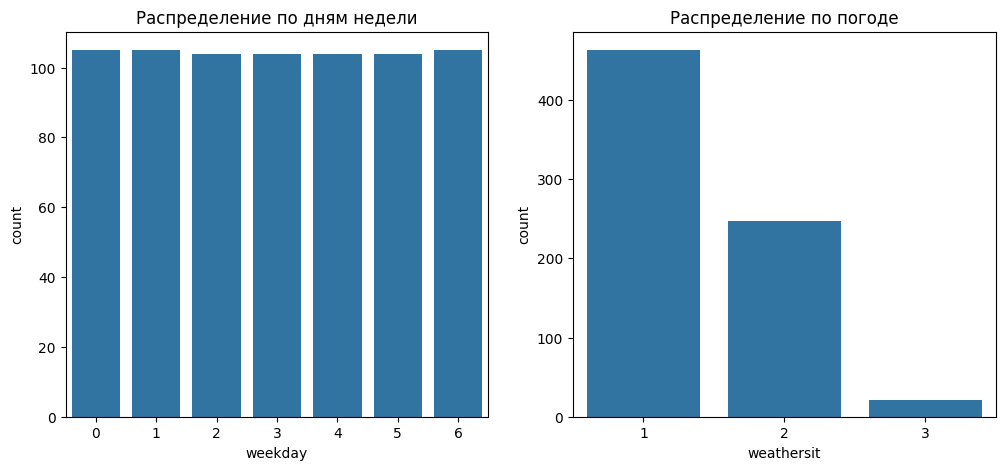

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x='weekday', data=df, ax=axes[0])
axes[0].set_title('Распределение по дням недели')
sns.countplot(x='weathersit', data=df, ax=axes[1])
axes[1].set_title('Распределение по погоде')
plt.show()

Датасет сформирован по дням: для каждого дня записаны погодные условия, календарные признаки и количество прокатов. По `weekday` видно, что дни недели представлены примерно равномерно. Это похоже на последовательные наблюдения за длительный период, а не на случайную выборку отдельных дней.

Ответ:

Распределение значений `weekday` близко к равномерному.


    
Ответ:

### 5. Распределение

Постройте распределение целевого признака.


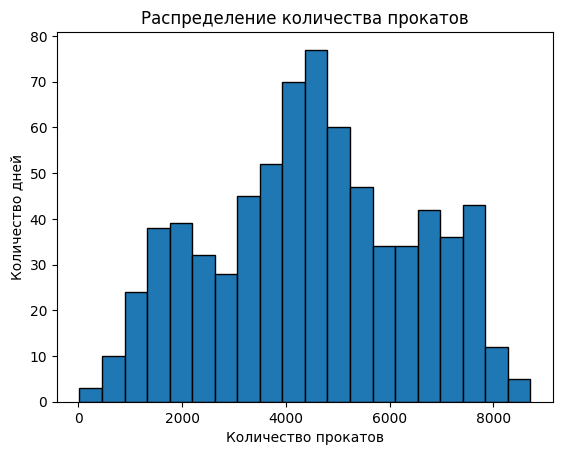

In [24]:
df['cnt'].plot(kind='hist', bins=20, edgecolor='black')
plt.xlabel('Количество прокатов')
plt.ylabel('Количество дней')
plt.title('Распределение количества прокатов')
plt.show()

В среднем получается примерно 3400 прокатов в день.

Ответ:

### 6. Совместное распределение признаков

Постройте график совместного распределения признаков температура и ощущение температуры.



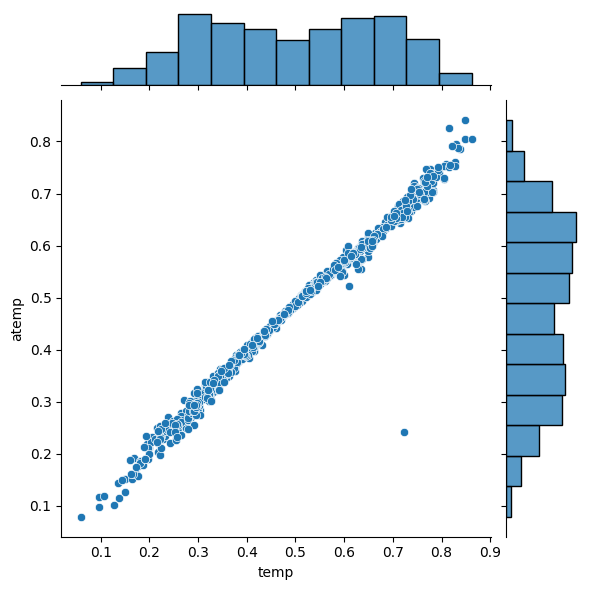

In [25]:
sns.jointplot(x='temp', y='atemp', data=df)
plt.show()

Да. `temp` и `atemp` почти совпадают и имеют очень сильную зависимость. Это логично, потому что температура по ощущениям рассчитывается на основе реальной температуры и других погодных условий. Поэтому эти два признака содержат очень похожую информацию.

Ответ:

### 7. Боксплот (ящик с усами)

Постройте график распределения (боксплот) количества прокатов велосипедов по месяцам в зависимости от того рабочий это день или нет.




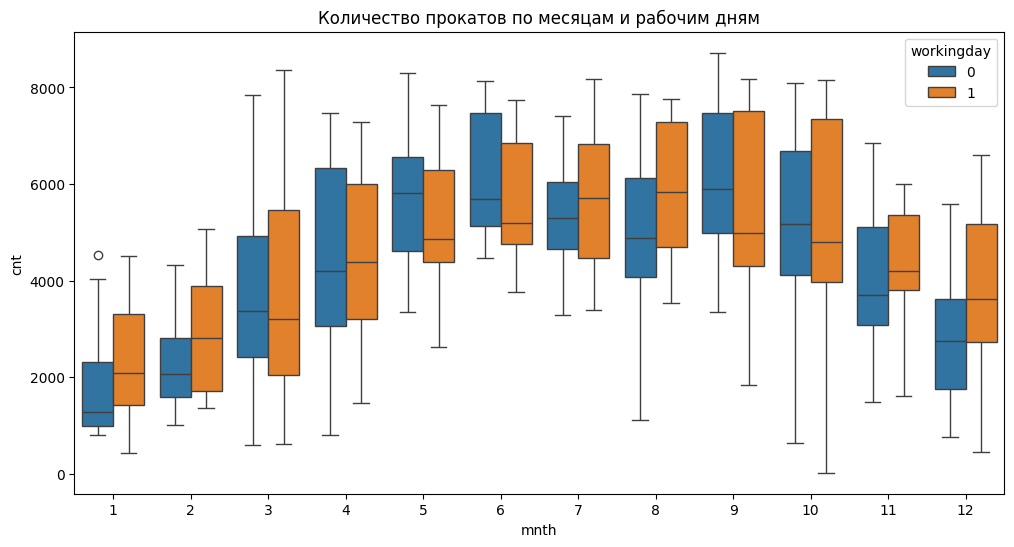

In [26]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='mnth', y='cnt', hue='workingday', data=df)
plt.title('Количество прокатов по месяцам и рабочим дням')
plt.show()

Количество прокатов зависит не только от рабочего дня, но и от сезона. В тёплое время года велосипедами чаще пользуются и в рабочие дни, и в выходные. В холодные месяцы ситуация меняется из-за погоды и сезона, поэтому соотношение между рабочими и выходными днями другое.

Ответ:

## Комплексное задание №3. Визуальный анализ данных. Часть 2

In [ ]:
#pip install seaborn==0.11.0
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#colab = False # если работаете на своём компьютере, в локальной среде, поставьте False
#if colab:
#    from google.colab import drive
#    drive.mount('/content/drive')

В этом задании Вам предлагается провести визуальный анализ датасета результатов экзаменов студентов  https://www.kaggle.com/spscientist/students-performance-in-exams.

Исходные данные загрузите самостоятельно!

In [33]:
#if colab:
#    df = pd.read_csv('/content/drive/My Drive/Data/StudentsPerformance.csv')
#else:
df = pd.read_csv(r"C:\Users\pasha\OneDrive\Рабочий стол\3 праткика Pandas\data\StudentsPerformance.csv")

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### Ход задания:

#### 1. Постройте 3 графика, показывающих распределение результатов экзаменов (каждый график на предмет).


Графики должны быть в одном ряду и у них должен быть общий заголовок "Результаты экзаменов".

Для результатов каждого экзамена посчитайте медианные значения.


Медиана по математике: 66.0
Медиана по чтению: 70.0
Медиана по письму: 69.0


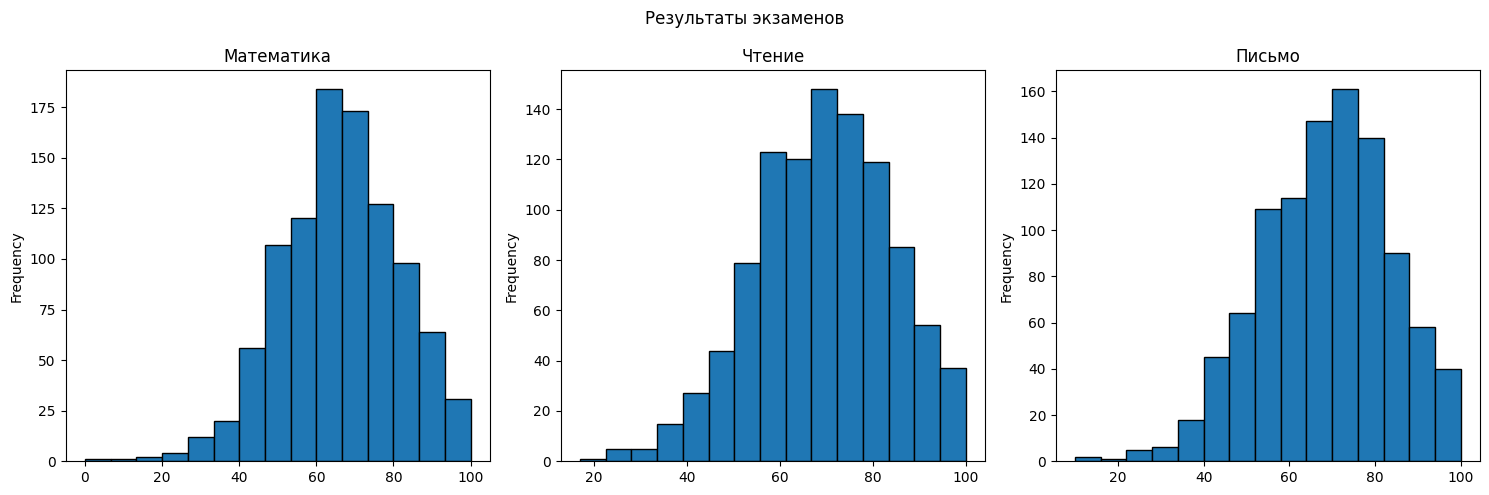

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

df['math score'].plot(kind='hist', bins=15, ax=axes[0], edgecolor='black', title='Математика')
df['reading score'].plot(kind='hist', bins=15, ax=axes[1], edgecolor='black', title='Чтение')
df['writing score'].plot(kind='hist', bins=15, ax=axes[2], edgecolor='black', title='Письмо')

fig.suptitle('Результаты экзаменов')
plt.tight_layout()

print('Медиана по математике:', df['math score'].median())
print('Медиана по чтению:', df['reading score'].median())
print('Медиана по письму:', df['writing score'].median())

#### 2. Образование родителей
Какие уровни образование есть в столбце *'parental level of education'* и сколько строк в датафрейме соответствует каждому уровню?

Постройте график и ответьте на вопрос ниже

Отличаются ли баллы по математике у детей с разным образованием родителей?
Постройте график, где по оси Х находятся уровни образования родителей, а по У - баллы по математике.


parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64


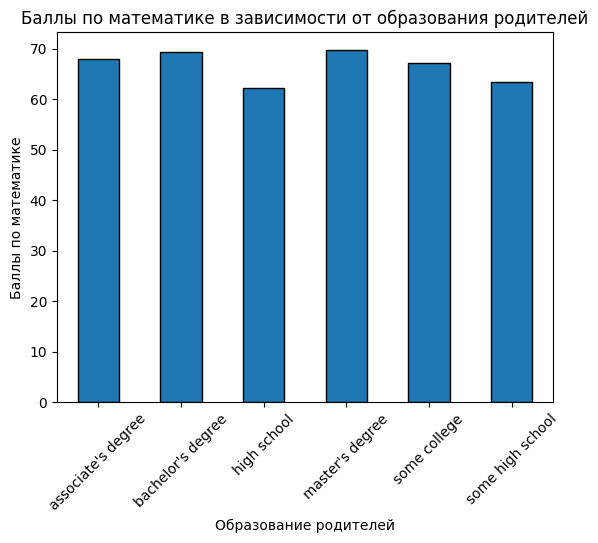

In [35]:
print(df['parental level of education'].value_counts())

df.groupby('parental level of education')['math score'].mean().plot(kind='bar', edgecolor='black')
plt.xlabel('Образование родителей')
plt.ylabel('Баллы по математике')
plt.title('Баллы по математике в зависимости от образования родителей')
plt.xticks(rotation=45)
plt.show()

#### 3. Выведите число студенток, набравших больше 90 баллов по всем предметам.


In [36]:
students = df[
    (df['gender'] == 'female') &
    (df['math score'] > 90) &
    (df['reading score'] > 90) &
    (df['writing score'] > 90)
]
len(students)

17

#### 4. Сравните баллы у студентов разных полов. Используя agg() выведите минимальное, максимальное и медианное значение


In [37]:
df.groupby('gender')[['math score', 'reading score', 'writing score']].agg(['min', 'max', 'median'])

math score             reading score             writing score       \
              min  max median           min  max median           min  max   
gender                                                                       
female          0  100   65.0            17  100   73.0            10  100   
male           27  100   69.0            23  100   66.0            15  100   

               
       median  
gender         
female   74.0  
male     64.0

#### 5. Выясните, влияет ли обед и подготовка к тесту на средний балл студентов разного пола
###### (подсказка: используете  [pd.agg()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.agg.html))

In [38]:
df['average'] = df[['math score', 'reading score', 'writing score']].mean(axis=1)
df.groupby(['gender', 'lunch', 'test preparation course'])['average'].agg(['mean', 'count'])

mean  count
gender lunch        test preparation course                  
female free/reduced completed                69.528571     70
                    none                     59.501401    119
       standard     completed                77.479532    114
                    none                     70.961240    215
male   free/reduced completed                65.721311     61
                    none                     58.323810    105
       standard     completed                73.513274    113
                    none                     65.486043    203

#### 6. Постройте график, показывающий зависимость уровня образования родителей от их расы

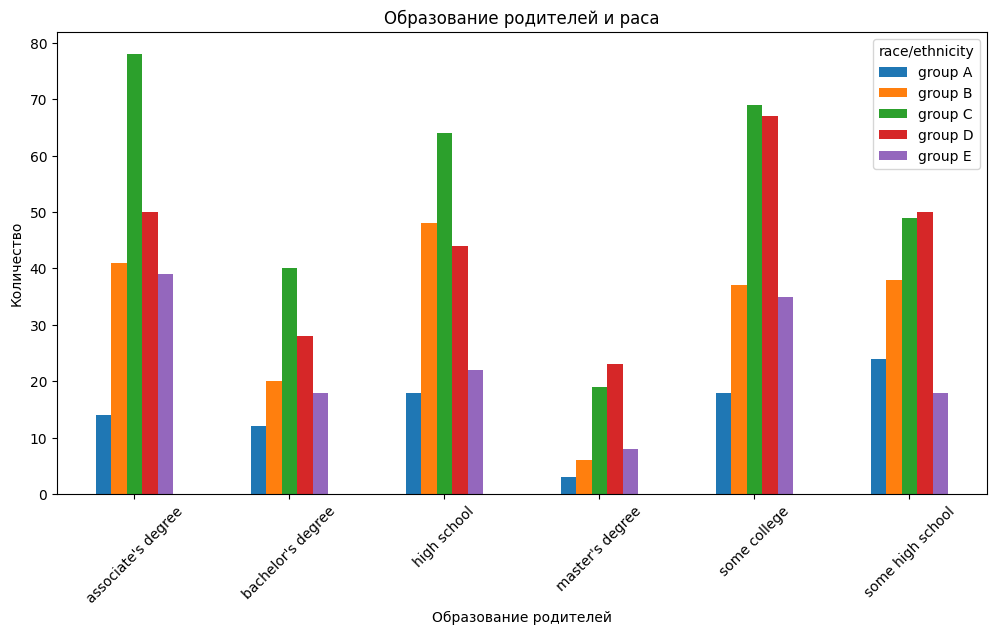

In [39]:
pd.crosstab(df['parental level of education'], df['race/ethnicity']).plot(kind='bar', figsize=(12, 6))
plt.xlabel('Образование родителей')
plt.ylabel('Количество')
plt.title('Образование родителей и раса')
plt.xticks(rotation=45)
plt.show()

#### 7. Постройте график, показывающий зависимость прохождения подготовительного теста от уровня образования родителей.


Кто чаще ходит на курсы: дети, родители которых закончили только старшую школу, или дети, чьи родители получили степень бакалавра\магистра?

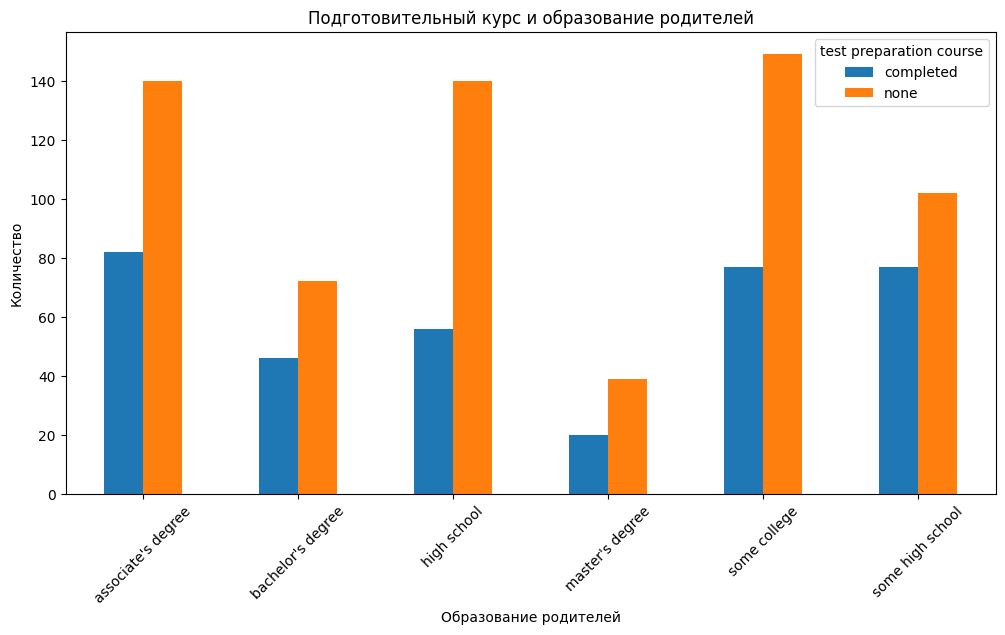

In [40]:
pd.crosstab(df['parental level of education'], df['test preparation course']).plot(kind='bar', figsize=(12, 6))
plt.xlabel('Образование родителей')
plt.ylabel('Количество')
plt.title('Подготовительный курс и образование родителей')
plt.xticks(rotation=45)
plt.show()

#### 8. Постройте plot.pie, показывающий, сколько людей сдали\не сдали экзамен по математике.

Сдавшим считается человек, набравший 40 баллов.

###### Подсказка: создайте столбец в датафрейме, который содержит результат сдачи (сдал или не сдал)

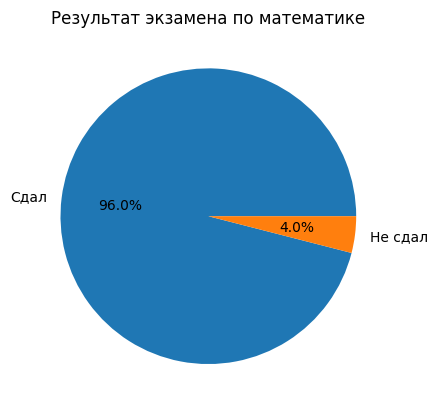

In [41]:
df['math_result'] = np.where(df['math score'] >= 40, 'Сдал', 'Не сдал')
df['math_result'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Результат экзамена по математике')
plt.ylabel('')
plt.show()

#### 9. Постройте plot.pie, показывающий распределение студентов по оценкам

Оценки студентов выставляются по шкале:<br>
0  - 40 marks : grade E<br>
41 - 60 marks : grade D<br>
60 - 70 marks : grade C<br>
70 - 80 marks : grade B<br>
80 - 90 marks : grade A<br>
90 - 100 marks : grade O<br>

Для этого посчитайте сумму результатов за 3 экзамена и найдите среднее. Оценка выставляется по среднему значению. Если студент не сдал математику(даже если средний балл выше 40), он получает Е

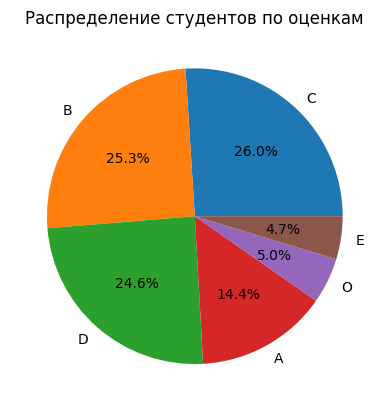

In [42]:
df['grade'] = pd.cut(
    df['average'],
    bins=[-1, 40, 60, 70, 80, 90, 100],
    labels=['E', 'D', 'C', 'B', 'A', 'O']
)
df.loc[df['math score'] < 40, 'grade'] = 'E'

df['grade'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Распределение студентов по оценкам')
plt.ylabel('')
plt.show()

#### 10. Постройте countplot, показывающий зависимость между итоговой оценкой студентов и его полом. Студенты какого пола получили больше оценок О, А, В

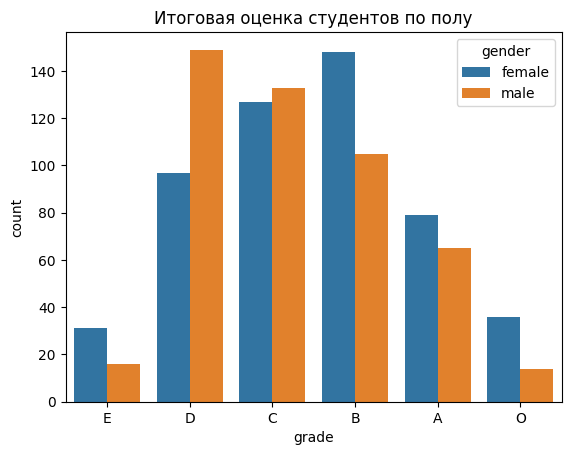

gender,female,male
grade,,
E,31,16
D,97,149
C,127,133
B,148,105
A,79,65
O,36,14


In [43]:
sns.countplot(x='grade', hue='gender', data=df)
plt.title('Итоговая оценка студентов по полу')
plt.show()

pd.crosstab(df['grade'], df['gender'])